This notebook compares 8 models:

- Base HMM
- Stay
- Stay + Turn
- Stay + Spatial
- Leaf
- Leaf + Stay
- Leaf + Stay + Turn
- Leaf + Stay + Spatial

In [11]:
println("$(Threads.nthreads()) Threads")
if Threads.nthreads() == 1
    println("Not running in parallel")
end

8 Threads


In [19]:
# Whether to recompute results
RERUN = false

false

In [13]:
using StatsPlots
using FileIO
using EM
include("hmm.jl")

run_hmm_em_leaf_stay_spatial (generic function with 1 method)

In [14]:
function show_results(results; mu=true, sigma=true)
    io = IOBuffer()
    
    print(io, "<pre>")
    print(io, "$(results.varnames)\n")
    print(io, "</pre>")

    if mu
        print(io, "β:<br/>")
        print(io, "<pre>")
        show(io, MIME"text/plain"(), round.(results.betas; digits=2))
        print(io, "</pre>")
    end
    
    if sigma
        print(io, "σ²:<br/>")
        print(io, "<pre>")
        show(io, MIME"text/plain"(), round.(results.sigma; digits=2))
        print(io, "</pre>")
    end
    
    my_string = String(take!(io))
    my_string = replace(my_string, r"[0-9]+×[0-9]+ Matrix{Float64}:\n" => "")
    my_string = replace(my_string, r"(-[0-9\.]+)" => s"<span style='color: red'>\1</span>")
    my_string = replace(my_string, "\n" => "<br/>")
    
    my_string
end

show_results (generic function with 1 method)

In [30]:
fns = [
    ("hmm", run_hmm_em),
    ("hmm_stay", run_hmm_em_stay),
    ("hmm_stay_turn", run_hmm_em_stay_turn),
    ("hmm_stay_spatial", run_hmm_em_stay_spatial),
    ("hmm_leaf", run_hmm_em_leaf),
    ("hmm_leaf_stay", run_hmm_em_leaf_stay),
    ("hmm_leaf_stay_turn", run_hmm_em_leaf_stay_turn),
    ("hmm_leaf_stay_spatial", run_hmm_em_leaf_stay_spatial),
    ]
fns_leaf = [
    ("hmm_leaf", run_hmm_em_leaf),
    ("hmm_leaf_stay", run_hmm_em_leaf_stay),
    ("hmm_leaf_stay_turn", run_hmm_em_leaf_stay_turn),
    ("hmm_leaf_stay_spatial", run_hmm_em_leaf_stay_spatial),
    ]
fns_nonleaf = [
    ("hmm", run_hmm_em),
    ("hmm_stay", run_hmm_em_stay),
    ("hmm_stay_turn", run_hmm_em_stay_turn),
    ("hmm_stay_spatial", run_hmm_em_stay_spatial),
    ]

4-element Vector{Tuple{String, Function}}:
 ("hmm", run_hmm_em)
 ("hmm_stay", run_hmm_em_stay)
 ("hmm_stay_turn", run_hmm_em_stay_turn)
 ("hmm_stay_spatial", run_hmm_em_stay_spatial)

In [18]:
if RERUN
    for animal in animals
        for (fname, fn) in fns
            results = fn(animal)
            save("results/biases/$(fname)_$(animal).jld2", "$(fname)_$(animal)", results)
        end
    end
end

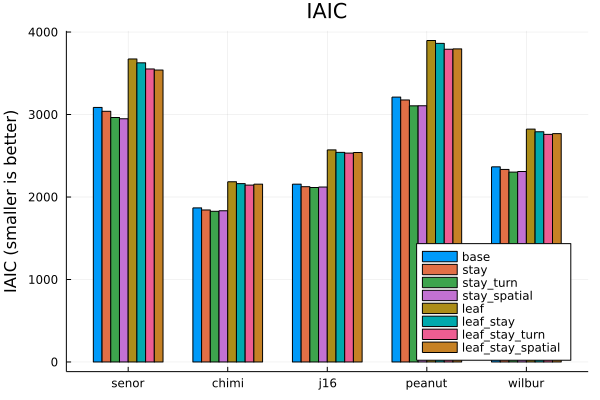

In [33]:
results = Dict()
aics = zeros(length(animals), length(fns))
for (i, animal) in enumerate(animals)
    for (j, (fname, fn)) in enumerate(fns)
        filename = "results/biases/$(fname)_$(animal).jld2"
        if (isfile(filename))
            results[(animal, fname)] = load("results/biases/$(fname)_$(animal).jld2", "$(fname)_$(animal)")
            aics[i, j] = iaic(results[(animal, fname)])
        end
    end
end
groupedbar(
    aics,
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels=["base" "stay" "stay_turn" "stay_spatial" "leaf" "leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    legend=:bottomright,
    ylabel="IAIC (smaller is better)",
    title="IAIC",
)

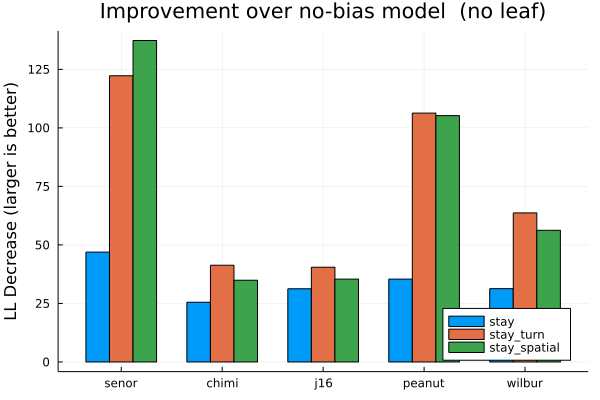

In [34]:
results = Dict()
aics = zeros(length(animals), length(fns_nonleaf))
for (i, animal) in enumerate(animals)
    for (j, (fname, fn)) in enumerate(fns_nonleaf)
        filename = "results/biases/$(fname)_$(animal).jld2"
        if (isfile(filename))
            results[(animal, fname)] = load("results/biases/$(fname)_$(animal).jld2", "$(fname)_$(animal)")
            aics[i, j] = iaic(results[(animal, fname)])
        end
    end
end
groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels=["stay" "stay_turn" "stay_spatial"],
    legend=:bottomright,
    ylabel="LL Decrease (larger is better)",
    title="Improvement over no-bias model  (no leaf)",
)

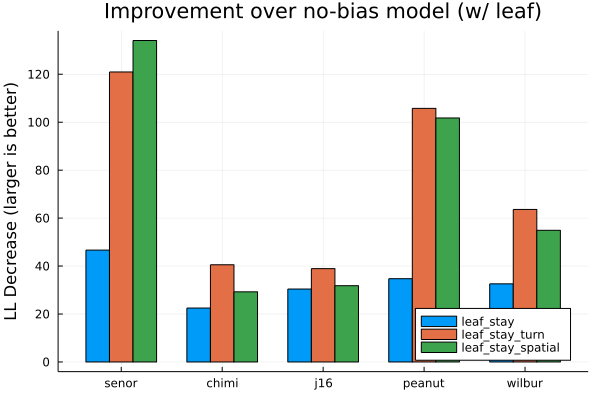

In [35]:
results = Dict()
aics = zeros(length(animals), length(fns_leaf))
for (i, animal) in enumerate(animals)
    for (j, (fname, fn)) in enumerate(fns_leaf)
        filename = "results/biases/$(fname)_$(animal).jld2"
        if (isfile(filename))
            results[(animal, fname)] = load("results/biases/$(fname)_$(animal).jld2", "$(fname)_$(animal)")
            aics[i, j] = iaic(results[(animal, fname)])
        end
    end
end
groupedbar(
    aics[:,1] .- aics[:,2:end],
    bar_position = :dodge, bar_width=0.7,
    xticks=(1:5, animals),
    labels=["leaf_stay" "leaf_stay_turn" "leaf_stay_spatial"],
    legend=:bottomright,
    ylabel="LL Decrease (larger is better)",
    title="Improvement over no-bias model (w/ leaf)",
)